In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")

print("Libraries Imported Successfully!")


In [1]:
# Load the dataset
df = pd.read_csv("superstore.csv", encoding="latin1")

# Display the first 5 rows
df.head()

NameError: name 'pd' is not defined

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("superstore.csv", encoding="latin1")

# Display first 5 rows
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,è®°å½æ°,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
# Display basic information about the dataset

print("Shape of Dataset:", df.shape)
print("\nColumn Names:\n")
print(df.columns)

print("\nDataset Information:\n")
df.info()

Shape of Dataset: (51290, 27)

Column Names:

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'è®°å½æ°', 'Order.Date', 'Order.ID',
       'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity',
       'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode',
       'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='str')

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer.ID     51290 non-null  str    
 4   Customer.Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   è®°å½æ°       51290 non-null  int6

In [5]:
# Check for missing values

print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
è®°å½æ°         0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64


In [6]:
# Display descriptive statistics

df.describe()

,Discount,è®°å½æ°,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [7]:
# Check duplicate rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Remove duplicate rows

df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (51290, 27)


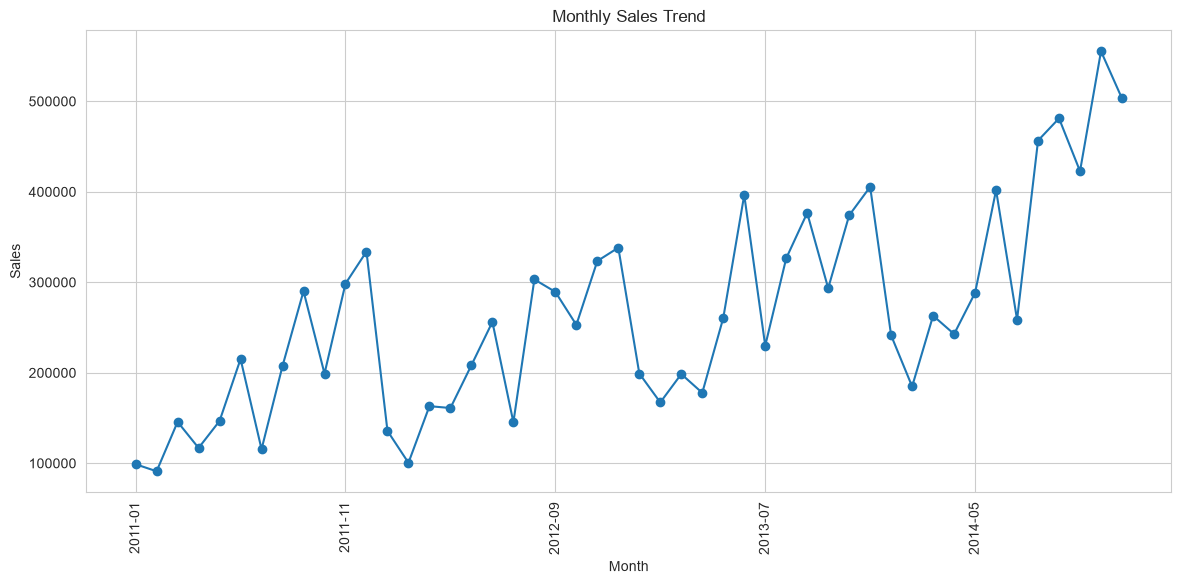

In [13]:
# Sales by Category

# Convert Order.Date to datetime

df['Order.Date'] = pd.to_datetime(df['Order.Date'])

# Extract Month-Year

df['Month'] = df['Order.Date'].dt.to_period('M').astype(str)

# Monthly Sales
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)

plt.show()

In [ ]:
# Convert Order Date to datetime

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Extract Month-Year

df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.show()


KeyError: 'Order Date'

In [11]:
print(df.columns.tolist())

['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'è®°å½\x95æ\x95°', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


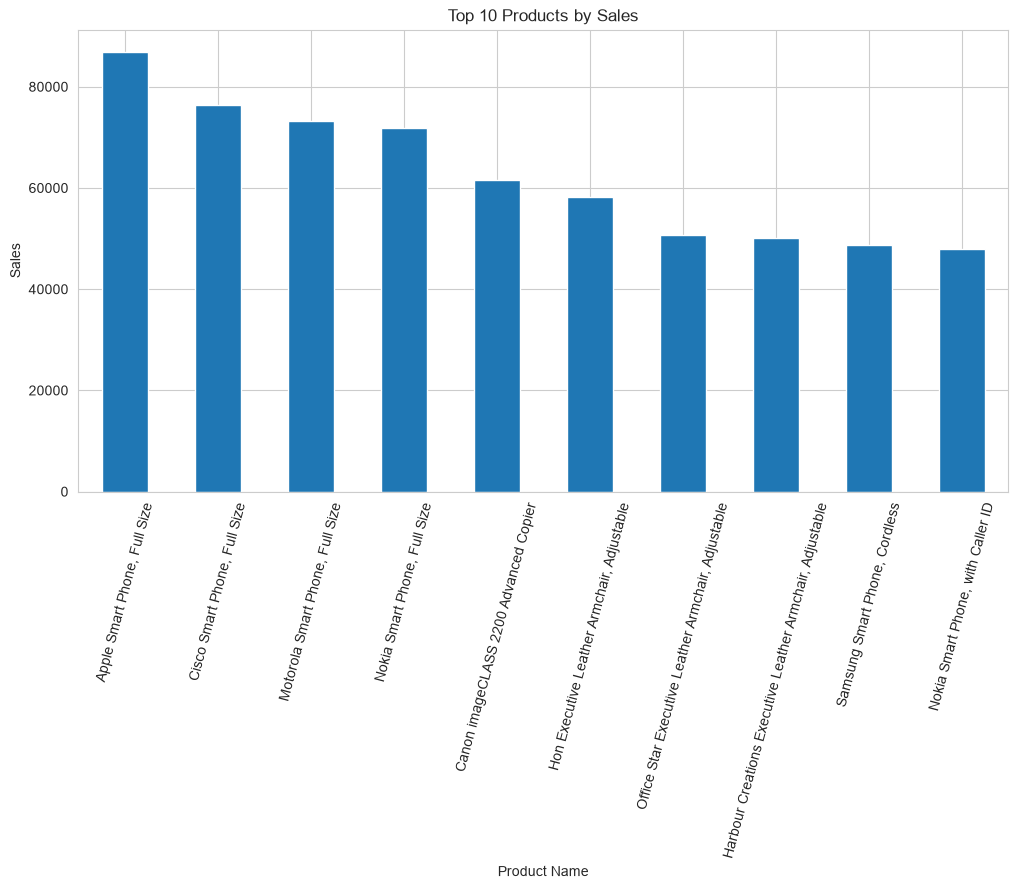

In [14]:
# Top 10 Products by Sales

top_products = df.groupby('Product.Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product Name")
plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.show()

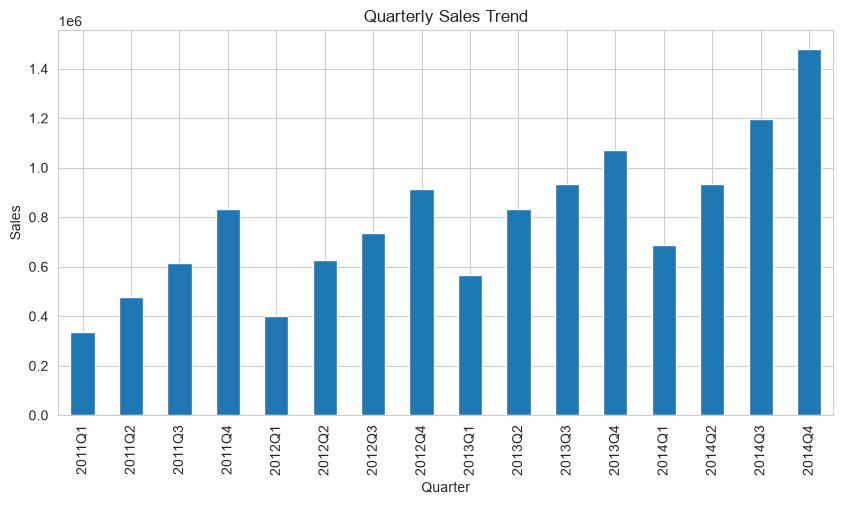

In [15]:
# Quarterly Sales Trend

df['Quarter'] = df['Order.Date'].dt.to_period('Q').astype(str)

quarterly_sales = df.groupby('Quarter')['Sales'].sum()

plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='bar')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.show()

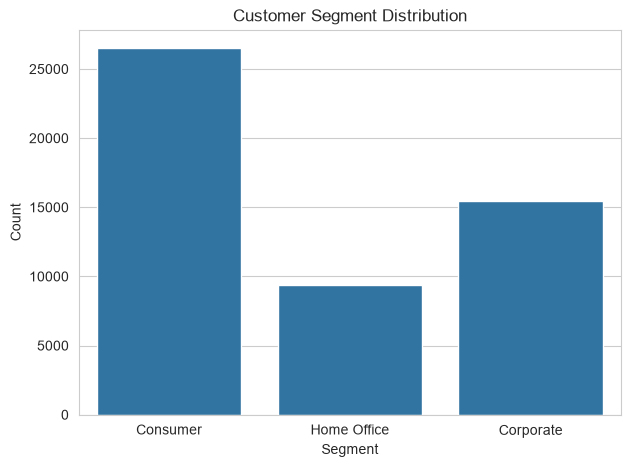

In [16]:
# Customer Segment Distribution

plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Segment')

plt.title("Customer Segment Distribution")
plt.xlabel("Segment")
plt.ylabel("Count")

plt.show()

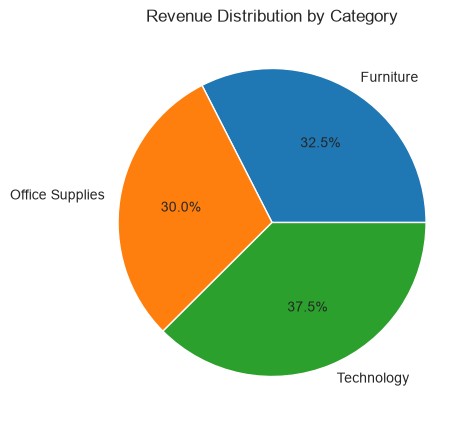

In [17]:
# Revenue by Category

category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))

category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.ylabel("")
plt.title("Revenue Distribution by Category")

plt.show()

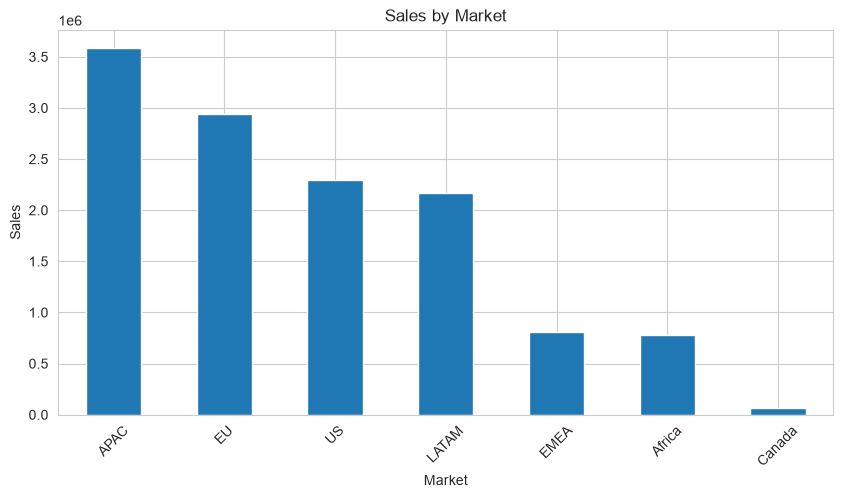

In [18]:
# Sales by Market

market_sales = df.groupby('Market')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

market_sales.plot(kind='bar')

plt.title("Sales by Market")
plt.xlabel("Market")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.show()

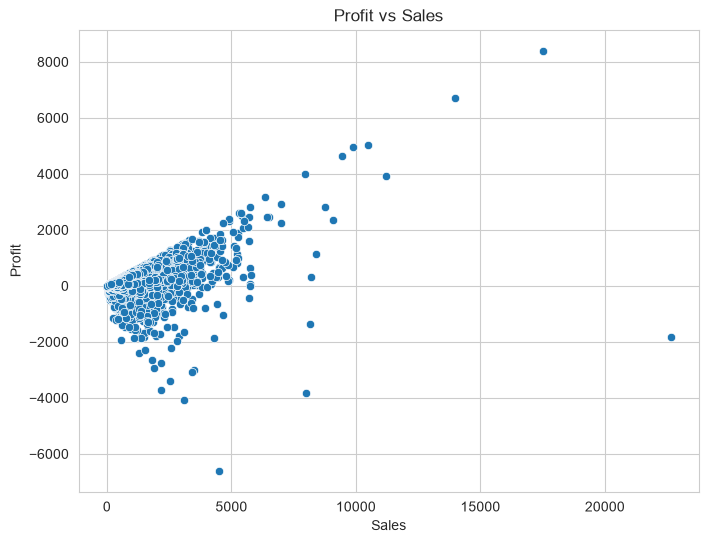

In [19]:
# Profit vs Sales

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='Sales', y='Profit')

plt.title("Profit vs Sales")

plt.show()

# Business Insights

- Technology products generated the highest sales.
- Sales show seasonal fluctuations across months and quarters.
- Consumer segment contributed the highest number of orders.
- Certain markets generated significantly higher revenue.
- Sales and Profit are positively correlated.
- Business should focus on high-performing products and profitable regions while improving sales in underperforming markets.
